# Q3: How do the reports of the category VBZ/ÖV cluster?
One category of the Züri wie neu reports are related to public transport. While quickly screening through the data, I observed that the word "Kalkbreite" was quite frequently present in the reports of the VBZ/ÖV category. By visualising the reports of this category I want to see wheter further "public transport problems" hotspots exist.

Summarized workflow:

0. Import all packages needed
1. Import all datasets needed for preparing the data for visualisation
2. Filter all reports of the category VBZ/ÖV
3. Import the map and labels for the map
4. Visualise the reports for the report
5. Create an interactive map to show to location of public transport related problems

## 0. Import section

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from pathlib import Path
#from matplotlib_scalebar.scalebar import ScaleBar

import sys
sys.path.append("../scripts")

from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_result_to_png #type: ignore

# 1. Import the spatially joined report dataset

In [2]:
# import the dataset:
reports_full=import_preprocessed_data("reports_quartiere_sjoin.gpkg")

reports_full.head(2)

The active geometry column of this geodataframe is called 'geometry'.


,service_request_id,requested_datetime,e,n,service_code,description,index_right,qnr,qname,knr,kname,geometry
0,1,2013-03-14 15:16:15,2678968,1247548,Strasse/Trottoir/Platz,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,16,91,Albisrieden,9,Kreis 9,POINT (2678968 1247548)
1,2,2013-03-14 15:17:57,2680746,1249916,Strasse/Trottoir/Platz,Vermessungs: Vermessungspunkt ist nicht mehr b...,20,101,Höngg,10,Kreis 10,POINT (2680746 1249916)


## 2. Filter for the category VBZ/ÖV 
In this step, I want to filter the reports to create a new subset called reports_public_transport, containing all reports of the VBZ/ÖV category.

In [3]:
# filter for the certain category: --> actually we could as well make a function for this...
reports_public_transport=reports_full[reports_full["service_code"]=="VBZ/ÖV"]

print(reports_public_transport.shape) #roughly 1900 reports relating public transport
reports_public_transport.head(2)

(1898, 12)


,service_request_id,requested_datetime,e,n,service_code,description,index_right,qnr,qname,knr,kname,geometry
5910,6515,2015-06-08 17:36:42,2683769,1252186,VBZ/ÖV,Ein Gleisst: Ein Gleisstoss verursacht starken...,32,119,Seebach,11,Kreis 11,POINT (2683769 1252186)
6042,6659,2015-07-15 17:43:04,2682785,1251946,VBZ/ÖV,Lose Sitzba: Lose Sitzbank-Holzlatte /Sitzfläc...,19,115,Oerlikon,11,Kreis 11,POINT (2682785 1251946)


## 3. Import the data needed for the visualisations
For the subsequent visualisations I would like to use the _map layer of the quartiere dataset, as it is recommended for data visualisations. Further, the labels are loaded as well, as they may be implemented into the interactive map. 

In [4]:
# Load the map of the neighborhoods
quartiere_map=import_preprocessed_data("quartiere_map.gpkg")

# Load the labels of the map
quartiere_labels=import_preprocessed_data("quartiere_labels.gpkg")

# Load the public tranport lines
# first preprocess them!!!

The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.


In [5]:
display(quartiere_map.head(2))
display(quartiere_labels.head(2))

,qnr,qname,knr,kname,geometry
0,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457.034 1246514.804, 2684466.315..."
1,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.383 1246512.719, 2684458.291..."


,name,kuerzel,geometry
0,Affoltern,111,POINT (2680575.711 1253034.933)
1,Seebach,119,POINT (2683071.957 1253148.375)


## 4. Create a short and simple visualisation for the report
As a visual map unfortunately cannot be implemented into a .pdf file, I will create a simple (probably quite messy) map that shows the locations of the public transport related reports in Zurich. The idea is to use the quartiere_map polygons as the background. Then, I will plot the report polygons on top. 

NOTE: I am aware that the individual report points will be hard to distinguish. This map is only created because the interactive map cannot be displayed in the .pdf file.

Text(0.5, 1.0, "Public Transport Related Reports of the 'Züri wie neu' platform")

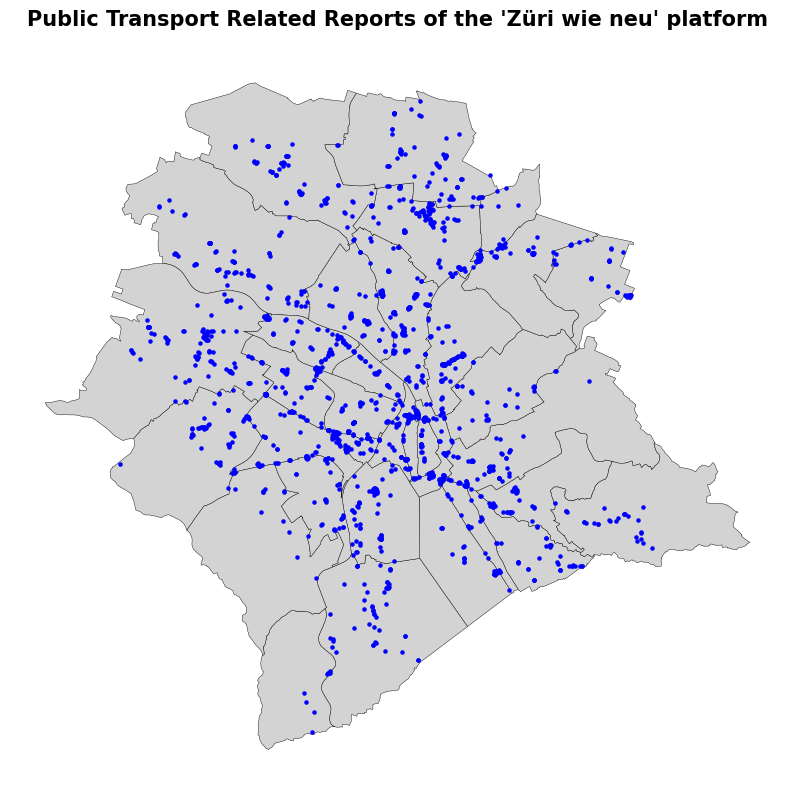

In [6]:
fig, ax=plt.subplots(figsize=(10,10))

#plot the layers
quartiere_map.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3, zorder=0)
reports_public_transport.plot(ax=ax, color="blue", markersize=5, zorder=1)

#set all further aesthetics
ax.axis("off")
ax.set_title("Public Transport Related Reports of the 'Züri wie neu' platform", fontsize=15, fontweight="bold")

https://www.stadt-zuerich.ch/geodaten/download/108?format=128
Daten des ÖV von hier